In [1]:
# importing relevant libraries
import pandas as pd
import numpy as np
import json
import os
from itertools import chain

# import boto3

from tqdm.notebook import tqdm_notebook
import time

import csv
import re

# display all rows & columns
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# show all outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Disable warnings
import warnings
warnings.filterwarnings("ignore")

**Import data for analysis**

In [2]:
# Import data
attrition_list = 'Hopeliner Copy of Sample 2022 Attrition List.xlsx'
responses = 'TTEC Interviews (Responses).xlsx'

attrition_df = pd.read_excel(attrition_list)
response_df = pd.read_excel(responses)


**Pre-processing of Dataset**

In [3]:
# Strip column names
attrition_df.columns = [x.strip() for x in attrition_df.columns]
response_df.columns = [x.strip() for x in response_df.columns]

# Response df - pre-processing
response_df.rename(columns =  {'Read Call Opening: \nHi (First Name), thank you for making time for this short interview or chat with us. As shared in our (email/ SMS) exchange, my name is (Interviewer Name). I am from e-BI Solutions. We are working with TTEC to find ways to improve their employee experience so we are grateful that you made time for this.':'Read Call Opening',
                              'Confidentiality Notice and Consent:\nPlease note that we will treat our conversation with confidentiality and only disclose information to the extent you wish to share them with TTEC. Our goal is to help them improve the employee experience through an unbiased study and analysis of the data we gather. We will ask for your sign-off on the final notes we will include in the study. Do you agree and consent to this interview/ short chat? (Share option to record video/ audio/ transcript only)\n\n(Wait for response. Proceed with questions as appropriate)': 'Confidentiality Notice and Consent',
                              }, inplace = True)

cols = ['Stated Reason for Leaving TTEC', 'Other considerations for leaving', 'Top 3 Low lights and impact to them',
'Highlights of their stay with TTEC', 'Suggestions on redesigning the experience',
'What would make you consider returning or referring friends and family members to TTEC?',
'Any questions for e-BI or TTEC?']

for col in cols:
    response_df[col] = response_df[col].astype(str)
    
# Add a new column for all reasons for leaving
response_df['All Leaving Reasons'] = response_df['Stated Reason for Leaving TTEC'] + " " + response_df['Other considerations for leaving']

## Pre-processing Descriptive Data

In [4]:
# pip install gensim
# pip install nltk
# pip install matplotlib
# pip install advertools
# Run 'python -m nltk.downloader all' on ubuntu
# pip install typing-extensions --upgrade

In [5]:
#import modules
import nltk
import gensim
import advertools as adv
import matplotlib.pyplot
import os.path
from gensim import corpora
from gensim.models import LsiModel
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

# Latent Dirichlet Allocation (LDA) Topic Analysis Model

**Resources:**
- [Evaluate Topic Models: Latent Dirichlet Allocation (LDA)](https://towardsdatascience.com/evaluate-topic-model-in-python-latent-dirichlet-allocation-lda-7d57484bb5d0)

- [pyLDAvis: Topic Modelling Exploration Tool That Every NLP Data Scientist Should Know](https://neptune.ai/blog/pyldavis-topic-modelling-exploration-tool-that-every-nlp-data-scientist-should-know)

In [6]:
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords

# Stop words
stop_words = stopwords.words('english') + list(adv.stopwords['tagalog'])

# Functions
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]

def preprocess_data_indiv(doc_set):
    """
    Input  : docuemnt list
    Purpose: preprocess text (tokenize, removing stopwords, and stemming)
    Output : preprocessed text
    """
    # initialize regex tokenizer
    tokenizer = RegexpTokenizer(r'\w+')
    # create English & Tagalog stop words list
    en_stop = set(stopwords.words('english') + list(adv.stopwords['tagalog']))
    # Create p_stemmer of class PorterStemmer
    p_stemmer = PorterStemmer()
    # list for tokenized documents in loop
    texts = []
    # loop through document list
    for i in doc_set:
        # clean and tokenize document string
        raw = i.lower()
        tokens = tokenizer.tokenize(raw)
        # remove stop words from tokens
        stopped_tokens = [i for i in tokens if not i in en_stop]
        # stem tokens
        #stemmed_tokens = [p_stemmer.stem(i) for i in stopped_tokens]
        # add tokens to list
        texts.append(stopped_tokens)
    return texts


In [7]:
# NLTK Stop words
# import nltk
# nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english') + list(adv.stopwords['tagalog'])
stop_words.extend(['from', 'subject', 're', 'edu', 'use','ttec'])
# Define functions for stopwords, bigrams, trigrams and lemmatization
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]
def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]
def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [8]:
# Create a copy of the original response dataframe
analysis_df = response_df.copy()

> 1) Remove punctuations, digits and stop words from text

In [9]:
# Remove punctuations & digits
import re
from string import digits
remove_digits = str.maketrans('', '', digits) # remove digits

for col in cols:
    analysis_df[col] = analysis_df[col].apply(lambda x: re.sub(r'[^\w\s]', '', x).translate(remove_digits).strip().lower())

In [10]:
import spacy
# !python -m spacy download en_core_web_lg 
# !python -m spacy download en_core_web_sm

In [11]:
# Remove stop words
data = analysis_df['Stated Reason for Leaving TTEC'].to_list() # field to analyse (MANUAL INPUT)
data_words = list(sent_to_words(data)) # convert words in response to list of words

# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)
# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

data_words_nostops = remove_stopwords(data_words) # remove stop words

# Form Bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

# Initialize spacy 'en' model, keeping only tagger component (for efficiency)
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Do lemmatization keeping only noun, adj, vb, adv
data_lemmatized = lemmatization(data_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

2022-12-21 08:56:37,274 | INFO | phrases.py:497 | learn_vocab | collecting all words and their counts
2022-12-21 08:56:37,275 | INFO | phrases.py:502 | learn_vocab | PROGRESS: at sentence #0, processed 0 words and 0 word types
2022-12-21 08:56:37,279 | INFO | phrases.py:525 | learn_vocab | collected 1810 word types from a corpus of 1639 words (unigram + bigrams) and 107 sentences
2022-12-21 08:56:37,279 | INFO | phrases.py:580 | add_vocab | using 1810 counts as vocab in Phrases<0 vocab, min_count=5, threshold=100, max_vocab_size=40000000>
2022-12-21 08:56:37,280 | INFO | phrases.py:497 | learn_vocab | collecting all words and their counts
2022-12-21 08:56:37,281 | INFO | phrases.py:502 | learn_vocab | PROGRESS: at sentence #0, processed 0 words and 0 word types
2022-12-21 08:56:37,290 | INFO | phrases.py:525 | learn_vocab | collected 1810 word types from a corpus of 1639 words (unigram + bigrams) and 107 sentences
2022-12-21 08:56:37,291 | INFO | phrases.py:580 | add_vocab | using 1810

> 2) Create a corpus

In [12]:
import gensim.corpora as corpora

def prepare_corpus(doc_clean):
    """
    Input  : clean document
    Purpose: create term dictionary of our courpus and Converting list of documents (corpus) into Document Term Matrix
    Output : term dictionary and Document Term Matrix
    """
    # Creating the term dictionary of our courpus, where every unique term is assigned an index. dictionary = corpora.Dictionary(doc_clean)
    dictionary = corpora.Dictionary(doc_clean)
    # Converting list of documents (corpus) into Document Term Matrix using dictionary prepared above.
    doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]
    # generate LDA model
    return dictionary,doc_term_matrix

In [13]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_lemmatized)
# Create Corpus
texts = data_lemmatized
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

2022-12-21 08:56:39,132 | INFO | dictionary.py:209 | add_documents | adding document #0 to Dictionary(0 unique tokens: [])
2022-12-21 08:56:39,135 | INFO | dictionary.py:214 | add_documents | built Dictionary(343 unique tokens: ['anxiety', 'depression', 'diagnosed', 'back', 'future']...) from 107 documents (total 790 corpus positions)


> 3) LDA Model 

In [14]:
from pprint import pprint

In [15]:
# number of topics
num_topics = 10

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics,
                                      random_state=3,
                                      chunksize=100,
                                       passes=10,
                                       per_word_topics=True)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

2022-12-21 08:56:41,040 | INFO | ldamodel.py:557 | init_dir_prior | using symmetric alpha at 0.1
2022-12-21 08:56:41,042 | INFO | ldamodel.py:557 | init_dir_prior | using symmetric eta at 0.1
2022-12-21 08:56:41,043 | INFO | ldamodel.py:481 | __init__ | using serial LDA version on this node
2022-12-21 08:56:41,046 | INFO | ldamulticore.py:238 | update | running online LDA training, 10 topics, 10 passes over the supplied corpus of 107 documents, updating every 700 documents, evaluating every ~107 documents, iterating 50x with a convergence threshold of 0.001000
2022-12-21 08:56:41,057 | INFO | ldamulticore.py:279 | update | training LDA model using 7 processes
2022-12-21 08:56:41,142 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 0, dispatched chunk #0 = documents up to #100/107, outstanding queue size 1
2022-12-21 08:56:41,147 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 0, dispatched chunk #1 = documents up to #107/107, outstanding queue size 2
2022-12-21 08:56:43,45

2022-12-21 08:56:43,564 | INFO | ldamodel.py:1171 | show_topics | topic #4 (0.100): 0.083*"personal" + 0.056*"reason" + 0.027*"account" + 0.027*"company" + 0.027*"morning" + 0.018*"due" + 0.018*"work" + 0.018*"shift" + 0.018*"growth" + 0.018*"take"
2022-12-21 08:56:43,565 | INFO | ldamodel.py:1171 | show_topics | topic #5 (0.100): 0.045*"employee" + 0.036*"time" + 0.027*"leave" + 0.027*"enough" + 0.025*"focus" + 0.025*"study" + 0.025*"need" + 0.018*"former" + 0.018*"working" + 0.018*"go"
2022-12-21 08:56:43,565 | INFO | ldamodel.py:1171 | show_topics | topic #9 (0.100): 0.032*"supervisor" + 0.026*"take" + 0.020*"work" + 0.020*"due" + 0.020*"care" + 0.020*"go" + 0.019*"need" + 0.019*"especially" + 0.014*"ask" + 0.014*"training"
2022-12-21 08:56:43,566 | INFO | ldamodel.py:1171 | show_topics | topic #0 (0.100): 0.065*"opportunity" + 0.042*"look" + 0.036*"salary" + 0.036*"well" + 0.032*"issue" + 0.028*"new" + 0.022*"arrangement" + 0.022*"due" + 0.021*"account" + 0.021*"high"
2022-12-21 08

2022-12-21 08:56:43,662 | INFO | ldamodel.py:1171 | show_topics | topic #1 (0.100): 0.045*"pay" + 0.034*"want" + 0.034*"bill" + 0.023*"reason" + 0.023*"field" + 0.023*"diagnosed" + 0.023*"employee" + 0.023*"former" + 0.022*"examination" + 0.018*"health"
2022-12-21 08:56:43,662 | INFO | ldamodel.py:1049 | do_mstep | topic diff=0.013546, rho=0.315127
2022-12-21 08:56:43,667 | INFO | ldamodel.py:822 | log_perplexity | -7.884 per-word bound, 236.3 perplexity estimate based on a held-out corpus of 7 documents with 26 words
2022-12-21 08:56:43,668 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 9, dispatched chunk #0 = documents up to #100/107, outstanding queue size 1
2022-12-21 08:56:43,670 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 9, dispatched chunk #1 = documents up to #107/107, outstanding queue size 2
2022-12-21 08:56:43,685 | INFO | ldamodel.py:1171 | show_topics | topic #7 (0.100): 0.044*"leave" + 0.033*"go" + 0.033*"good" + 0.033*"decide" + 0.033*"health" + 0.02

[(0,
  '0.072*"opportunity" + 0.042*"look" + 0.041*"well" + 0.038*"salary" + '
  '0.032*"issue" + 0.028*"new" + 0.022*"arrangement" + 0.022*"due" + '
  '0.021*"account" + 0.021*"high"'),
 (1,
  '0.045*"pay" + 0.034*"want" + 0.034*"bill" + 0.023*"reason" + 0.023*"field" '
  '+ 0.023*"diagnosed" + 0.023*"employee" + 0.023*"former" + '
  '0.022*"examination" + 0.018*"health"'),
 (2,
  '0.034*"company" + 0.034*"look" + 0.034*"incentive" + 0.033*"find" + '
  '0.023*"new" + 0.018*"change" + 0.018*"issue" + 0.018*"health" + '
  '0.018*"anxiety" + 0.018*"experience"'),
 (3,
  '0.050*"work" + 0.031*"family" + 0.028*"go" + 0.028*"decide" + 0.025*"time" '
  '+ 0.022*"board" + 0.022*"wfh" + 0.021*"salary" + 0.017*"problem" + '
  '0.017*"issue"'),
 (4,
  '0.096*"personal" + 0.070*"reason" + 0.026*"account" + 0.026*"company" + '
  '0.026*"morning" + 0.018*"due" + 0.018*"work" + 0.018*"shift" + '
  '0.018*"growth" + 0.018*"take"'),
 (5,
  '0.044*"employee" + 0.036*"time" + 0.027*"leave" + 0.027*"enou

> 4) Select optimal number of topics

In [16]:
# supporting function
def compute_coherence_values(corpus, dictionary, k, a, b):
    
    lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=k, 
                                           random_state=100,
                                           chunksize=100,
                                           passes=10,
                                           alpha=a,
                                           eta=b)
    
    coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
    
    return coherence_model_lda.get_coherence()

In [17]:
# Baseline coherence score
from gensim.models import CoherenceModel
# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nBaseline Coherence Score: ', coherence_lda)

2022-12-21 08:56:44,771 | INFO | probability_estimation.py:155 | p_boolean_sliding_window | using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2022-12-21 08:56:46,730 | INFO | text_analysis.py:530 | terminate_workers | 7 accumulators retrieved from output queue
2022-12-21 08:56:46,755 | INFO | text_analysis.py:552 | merge_accumulators | accumulated word occurrence stats for 100 virtual documents



Baseline Coherence Score:  0.388332470409335


In [18]:
# Optimize coherence score
import tqdm
grid = {}
grid['Validation_Set'] = {}
# Topics range
min_topics = 2
max_topics = 11
step_size = 1
topics_range = range(min_topics, max_topics, step_size)

# Alpha parameter
alpha = list(np.arange(0.01, 1, 0.3))
alpha.append('symmetric')
alpha.append('asymmetric')

# Beta parameter
beta = list(np.arange(0.01, 1, 0.3))
beta.append('symmetric')

# Validation sets
num_of_docs = len(corpus)
corpus_sets = [
#     gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.25)), 
#                gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.5)), 
               gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.75)), 
               corpus]

corpus_title = [
    #'25% Corpus','50% Corpus',
    '75% Corpus', '100% Corpus']

model_results = {'Validation_Set': [],
                 'Topics': [],
                 'Alpha': [],
                 'Beta': [],
                 'Coherence': []
                }

In [19]:
# # iterate through validation corpuses
# for i in tqdm_notebook(range(len(corpus_sets))):
#     # iterate through number of topics
#     for k in topics_range:
#         # iterate through alpha values
#         for a in alpha:
#             # iterare through beta values
#             for b in beta:
#                 # get the coherence score for the given parameters
#                 cv = compute_coherence_values(corpus=corpus_sets[i], dictionary=id2word, 
#                                               k=k, a=a, b=b)
#                 # Save the model results
#                 model_results['Validation_Set'].append(corpus_title[i])
#                 model_results['Topics'].append(k)
#                 model_results['Alpha'].append(a)
#                 model_results['Beta'].append(b)
#                 model_results['Coherence'].append(cv)


In [ ]:
# Create coherence dataframe
coherence_results = (pd.DataFrame(model_results)
                     .sort_values(by = 'Coherence')
                    )

In [ ]:
print("resume here!")

In [25]:
alpha

[0.01, 0.31, 0.61, 0.9099999999999999, 'symmetric', 'asymmetric']

,Validation_Set,Topics,Alpha,Beta,Coherence


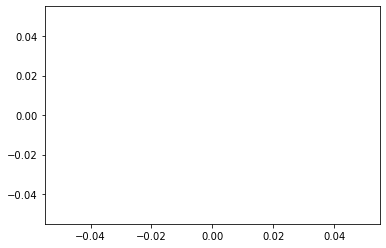

In [25]:
# Plot results - find optimal alpha & beta to find best coherence, then reconfigure alpha & beta
plot_df = (coherence_results
             #.query("(Alpha != 'asymmetric') & (Alpha != 'symmetric') ", engine = 'python')
             #.query("(Validation_Set != '25% Corpus') & (Validation_Set != '50% Corpus')", engine = 'python')
             .query("(Alpha == 0.31) & (Beta == 0.31)", engine = 'python')
             .sort_values(by = 'Topics', ascending = False)             
            )
plot_df

# Plot
plt.plot(plot_df['Topics'].to_list(), plot_df['Coherence'].to_list())
plt.show()

In [26]:
# Select optimal alpha & beta
(coherence_results
 .query("Topics == 5")
 .sort_values(by = 'Coherence', ascending = False)
)

,Validation_Set,Topics,Alpha,Beta,Coherence


> 5) Train final model with optimized hyperparameters

In [20]:
# Train final model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=5, 
                                           random_state=3,
                                           chunksize=100,
                                           passes=10,
                                           alpha='asymmetric',
                                           eta=0.9099999999999999)

2022-12-21 08:57:02,929 | INFO | ldamodel.py:564 | init_dir_prior | using asymmetric alpha [0.33283758, 0.22998512, 0.17569299, 0.14213862, 0.11934563]
2022-12-21 08:57:02,930 | INFO | ldamodel.py:481 | __init__ | using serial LDA version on this node
2022-12-21 08:57:02,932 | INFO | ldamulticore.py:238 | update | running online LDA training, 5 topics, 10 passes over the supplied corpus of 107 documents, updating every 700 documents, evaluating every ~107 documents, iterating 50x with a convergence threshold of 0.001000
2022-12-21 08:57:02,935 | INFO | ldamulticore.py:279 | update | training LDA model using 7 processes
2022-12-21 08:57:03,005 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 0, dispatched chunk #0 = documents up to #100/107, outstanding queue size 1
2022-12-21 08:57:03,010 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 0, dispatched chunk #1 = documents up to #107/107, outstanding queue size 2
2022-12-21 08:57:04,923 | INFO | ldamodel.py:1171 | show_topics

2022-12-21 08:57:05,037 | INFO | ldamodel.py:1171 | show_topics | topic #0 (0.333): 0.019*"personal" + 0.018*"issue" + 0.017*"reason" + 0.014*"opportunity" + 0.014*"go" + 0.014*"leave" + 0.012*"health" + 0.012*"salary" + 0.011*"due" + 0.010*"look"
2022-12-21 08:57:05,038 | INFO | ldamodel.py:1171 | show_topics | topic #1 (0.230): 0.013*"work" + 0.012*"employee" + 0.010*"pay" + 0.009*"need" + 0.008*"want" + 0.008*"get" + 0.006*"account" + 0.006*"salary" + 0.006*"former" + 0.006*"bill"
2022-12-21 08:57:05,039 | INFO | ldamodel.py:1171 | show_topics | topic #2 (0.176): 0.008*"prepare" + 0.008*"board" + 0.008*"exam" + 0.006*"attack" + 0.006*"first" + 0.006*"welcome" + 0.006*"bpo" + 0.006*"dissolve" + 0.006*"overwhelmed" + 0.006*"know"
2022-12-21 08:57:05,039 | INFO | ldamodel.py:1171 | show_topics | topic #3 (0.142): 0.023*"work" + 0.016*"salary" + 0.013*"go" + 0.013*"time" + 0.012*"family" + 0.011*"account" + 0.011*"decide" + 0.009*"wfh" + 0.009*"problem" + 0.009*"employee"
2022-12-21 08:

2022-12-21 08:57:05,145 | INFO | ldamodel.py:1171 | show_topics | topic #4 (0.119): 0.011*"former" + 0.011*"employee" + 0.008*"morning" + 0.008*"shift" + 0.008*"company" + 0.008*"application" + 0.008*"training" + 0.005*"bring" + 0.005*"night" + 0.005*"bedridden"
2022-12-21 08:57:05,145 | INFO | ldamodel.py:1049 | do_mstep | topic diff=0.001498, rho=0.315127
2022-12-21 08:57:05,148 | INFO | ldamodel.py:822 | log_perplexity | -6.462 per-word bound, 88.1 perplexity estimate based on a held-out corpus of 7 documents with 26 words
2022-12-21 08:57:05,149 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 9, dispatched chunk #0 = documents up to #100/107, outstanding queue size 1
2022-12-21 08:57:05,150 | INFO | ldamulticore.py:294 | update | PROGRESS: pass 9, dispatched chunk #1 = documents up to #107/107, outstanding queue size 2
2022-12-21 08:57:05,168 | INFO | ldamodel.py:1171 | show_topics | topic #0 (0.333): 0.020*"personal" + 0.018*"issue" + 0.017*"reason" + 0.014*"go" + 0.014*"op

> 4) Visualizing topics

For (1), you can manually select each topic to view its top most frequent and/or “relevant” terms, using different values of the λ parameter. This can help when you’re trying to assign a human interpretable name or “meaning” to each topic.

For (2), exploring the Intertopic Distance Plot can help you learn about how topics relate to each other, including potential higher-level structure between groups of topics.

**Interpretation:**


*Bar chart*
- Each bubble represents a topic. The larger the bubble, the higher percentage of the number of responses in the corpus is about that topic.
- Blue bars represent the overall frequency of each word in the corpus. If no topic is selected, the blue bars of the most frequently used words will be displayed.
- Red bars give the estimated number of times a given term was generated by a given topic. The word with the longest red bar is the word that is used the most by the responses belonging to that topic.
- <u>*Lambda*</u> -- Decreasing the lambda parameter, increases the weight of the ratio of the frequency of word given the topic / Overall frequency of the word in the documents. Important words for the given topic moves upward.
    - Lambda = 1, top words by frequency
    - Lambda = 0, top words by relevance to topic

*Bubble plot*
- The further the bubbles are away from each other, the more different they are. 
- The larger the bubble, the more frequent is the topic in the documents.
- Distance between the topics is an approximation of semantic relationship between the topics.
- The topic which shares common words will be overlapping (closer in distance) in comparison to the non-overlapping topic.
- A good topic model will have big and non-overlapping bubbles scattered throughout the chart. As we can see from the graph, the bubbles are clustered within one place.
- A topic model with a low number of topics will have big non-overlapping bubbles, scattered throughout the chart whereas, the topic model with a high number of topics, will have many overlapping small size bubbles, clustered in the chart.


In [21]:
import pyLDAvis.gensim
import pickle 
import pyLDAvis

In [22]:
# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
LDAvis_prepared

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.051232  0.004851       1        1  47.798935
1      0.024397  0.008215       2        1  21.491149
3      0.004977 -0.031335       3        1  19.020317
4      0.015482  0.009621       4        1   6.425378
2      0.006376  0.008648       5        1   5.264220, topic_info=         Term      Freq     Total Category  logprob  loglift
16       work  9.000000  9.000000  Default  30.0000  30.0000
182  employee  5.000000  5.000000  Default  29.0000  29.0000
183    former  3.000000  3.000000  Default  28.0000  28.0000
50       exam  2.000000  2.000000  Default  27.0000  27.0000
49      board  2.000000  2.000000  Default  26.0000  26.0000
..        ...       ...       ...      ...      ...      ...
16       work  0.227691  9.186791   Topic5  -5.2076  -0.7533
302   trainee  0.110400  1.486834   Topic5  -5.9314   0.3439
196  military  0.110417  1.527458   Topic5  -5.9313   0.3171
29       time  0.111243  6.337722   Topic5  -5.9238  -1.0983
56      leave  0.111033  6.101349   Topic5  -5.9257  -1.0622

[244 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
68        1  0.586372  account
68        2  0.146593  account
68        3  0.293186  account
243       3  0.599063   adjust
10        2  0.549285   affect
...     ...       ...      ...
16        2  0.217704     work
16        3  0.435408     work
256       1  0.833291  working
31        1  0.349569     year
31        3  0.349569     year

[220 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 4, 5, 3])

# Post-modeling Exploratory Data Analysis

*Assign respondents to their topic clusters*

In [23]:
# Topic distribution for the whole document. Each element in the list is a pair of a topic’s id, and the probability that was assigned to it.
topic_dist = list(lda_model.get_document_topics(corpus))


# Classify responses to topics
cluster = []
probability = []

for i in range(0, len(topic_dist)):
    clust = [x for x,y in topic_dist[i]]
    prob = [y for x,y in topic_dist[i]]
    get_index = prob.index(max(prob))
    max_val = topic_dist[i][get_index]
    cluster.append(max_val[0])
    probability.append(max_val[1])
    
# Add classification to df
analysis_df['Topic'] = cluster
analysis_df['Topic_Probability'] = probability

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [24]:
# Map topics to Oracle ID
id_topic_mapper = dict(zip(analysis_df['Oracle ID of former employee'], analysis_df['Topic']))
id_prob_mapper = dict(zip(analysis_df['Oracle ID of former employee'], analysis_df['Topic_Probability']))
id_rate_mapper = dict(zip(analysis_df['Oracle ID of former employee'], analysis_df['How would you rate your overall experience with TTEC on a scale of 1 to 5? 5 being Very Good and 1 being Not Good']))

# For those with missing Oracle ID, map to names
name_mapper = (analysis_df[~analysis_df.applymap(np.isreal)['Oracle ID of former employee']]
               .assign(Name = lambda x: x['Name of former employee'].apply(lambda x: x.upper()))
               [['Name','Topic']]
                
                     .set_index("Name").to_dict()['Topic']
)

name_mapper2 = (analysis_df[~analysis_df.applymap(np.isreal)['Oracle ID of former employee']]
               .assign(Name = lambda x: x['Name of former employee'].apply(lambda x: x.upper()))
               [['Name','Topic_Probability']]
                
                     .set_index("Name").to_dict()['Topic_Probability']
)

rating_mapper = (analysis_df[~analysis_df.applymap(np.isreal)['Oracle ID of former employee']]
               .assign(Name = lambda x: x['Name of former employee'].apply(lambda x: x.upper()))
               [['Name','How would you rate your overall experience with TTEC on a scale of 1 to 5? 5 being Very Good and 1 being Not Good']]
                
                     .set_index("Name").to_dict()['How would you rate your overall experience with TTEC on a scale of 1 to 5? 5 being Very Good and 1 being Not Good']
)

# Filter attrition df to contain respondents only
respondents_demog_df = (attrition_df
                         .assign(Topic1 = lambda x: x['EE Oracle Id'].map(id_topic_mapper),
                                 Prob1 = lambda x: x['EE Oracle Id'].map(id_prob_mapper),
                                 Rate1 = lambda x: x['EE Oracle Id'].map(id_rate_mapper),
                                 Name = lambda x: (x['First Name'] + " " + x['Last Name']).apply(lambda x: x.upper()),
                                 Topic = lambda x: np.where(x['Topic1'].isna(), x['Name'].map(name_mapper), x['Topic1']),
                                 Topic_Probability = lambda x: np.where(x['Prob1'].isna(), x['Name'].map(name_mapper2), x['Prob1']),
                                Rating = lambda x: np.where(x['Rate1'].isna(), x['Name'].map(rating_mapper), x['Rate1']),

                         )
                         .drop(['Topic1','Prob1','Rate1'], axis = 1)
                         .query("Topic.notna()", engine = 'python')
                         .sort_values(by = 'Topic')
                        )

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


> 1) How many respondents belong to each topic cluster & what is the average probability score?

In [25]:
# "Number of Employees per Cluster & Average Probability Score")
gen_stats = (analysis_df
             .groupby(['Topic']).agg({'Oracle ID of former employee':'nunique', 'Topic_Probability':'describe'})
             .reset_index()
            )

gen_stats

print("Number of Employees per Cluster & Average Probability Score")


/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Topic Oracle ID of former employee Topic_Probability                      \
        Oracle ID of former employee             count      mean       std   
0     0                           67              67.0  0.840337  0.118952   
1     1                           18              18.0  0.881645  0.055965   
2     2                            5               5.0  0.861518  0.051101   
3     3                           12              12.0  0.868545  0.130626   
4     4                            5               5.0  0.864821  0.089528   

                                                     
        min       25%       50%       75%       max  
0  0.332838  0.776805  0.865457  0.915638  0.983541  
1  0.794688  0.845460  0.881705  0.916048  0.979415  
2  0.788053  0.831232  0.883080  0.890607  0.914619  
3  0.534822  0.855742  0.914914  0.958427  0.967581  
4  0.763558  0.775085  0.896478  0.939160  0.949825

Number of Employees per Cluster & Average Probability Score


> 2) Tenure, Topic Probability, and Employee Count by By Attrition Stage

In [36]:
analysis_df.Timestamp.max()

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Timestamp('2022-12-17 20:04:01.312000')

In [33]:
respondents_demog_df.describe()

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,EE Oracle Id,Tenure In Months,Topic,Topic_Probability,Rating
count,1.070000e+02,107.000000,107.000000,107.000000,94.000000
mean,2.222704e+06,22.971963,0.785047,0.852583,4.180851
std,3.124793e+04,21.379084,1.228806,0.108453,0.775467
min,2.079476e+06,1.000000,0.000000,0.332838,1.000000
25%,2.213849e+06,6.500000,0.000000,0.810481,4.000000
50%,2.227052e+06,19.000000,0.000000,0.866705,4.000000
75%,2.242138e+06,29.500000,1.000000,0.922750,5.000000
max,2.264049e+06,127.000000,4.000000,0.983541,5.000000


In [26]:
(respondents_demog_df
 .groupby(['Topic','Stage Attrition']).agg({'EE Oracle Id':'nunique','Tenure In Months':['mean', 'std','median'],'Topic_Probability':['mean', 'std','median']})
 .unstack('Stage Attrition')
)

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


EE Oracle Id            Tenure In Months             \
                       nunique                        mean              
Stage Attrition Pre Production Production   Pre Production Production   
Topic                                                                   
0.0                          7         60         8.857143  26.233333   
1.0                          2         16         1.000000  25.000000   
2.0                          1          4         5.000000  10.000000   
3.0                          1         11         1.000000  32.727273   
4.0                          3          2         1.666667   4.500000   

                                                                     \
                           std                    median              
Stage Attrition Pre Production Production Pre Production Production   
Topic                                                                 
0.0                  11.710801  19.289381            3.0       21.5   
1.0                   0.000000  18.754555            1.0       19.5   
2.0                        NaN  10.392305            5.0       10.0   
3.0                        NaN  35.262135            1.0       22.0   
4.0                   0.577350   2.121320            2.0        4.5   

                Topic_Probability                                       \
                             mean                       std              
Stage Attrition    Pre Production Production Pre Production Production   
Topic                                                                    
0.0                      0.865399   0.837413       0.072237   0.123347   
1.0                      0.848727   0.885759       0.071707   0.055176   
2.0                      0.890607   0.854246            NaN   0.055939   
3.0                      0.959539   0.860273            NaN   0.133664   
4.0                      0.829489   0.917819       0.104373   0.030181   

                                           
                        median             
Stage Attrition Pre Production Production  
Topic                                      
0.0                   0.865356   0.865460  
1.0                   0.848727   0.881705  
2.0                   0.890607   0.857156  
3.0                   0.959539   0.902471  
4.0                   0.775085   0.917819

> 3) Tenure, Topic Probability, and Employee Count by By Job Name

In [27]:
(respondents_demog_df
 .groupby(['Topic','Job Name','Stage Attrition']).agg({'EE Oracle Id':'nunique','Tenure In Months':['mean', 'std','median']})
 .unstack('Job Name')
)

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


EE Oracle Id                                        \
                           nunique                                         
Job Name                     CSR I CSR II CSR III Chat Sales Associate I   
Topic Stage Attrition                                                      
0.0   Pre Production           2.0    5.0     NaN                    NaN   
      Production               7.0   39.0    11.0                    NaN   
1.0   Pre Production           1.0    1.0     NaN                    NaN   
      Production               2.0   11.0     1.0                    1.0   
2.0   Pre Production           1.0    NaN     NaN                    NaN   
      Production               NaN    4.0     NaN                    NaN   
3.0   Pre Production           NaN    1.0     NaN                    NaN   
      Production               4.0    5.0     1.0                    NaN   
4.0   Pre Production           2.0    1.0     NaN                    NaN   
      Production               NaN    2.0     NaN                    NaN   

                                          Tenure In Months             \
                                                      mean              
Job Name              ISR I TSR I TSR III            CSR I     CSR II   
Topic Stage Attrition                                                   
0.0   Pre Production    NaN   NaN     NaN         3.500000  11.000000   
      Production        NaN   1.0     2.0        33.142857  24.564103   
1.0   Pre Production    NaN   NaN     NaN         1.000000   1.000000   
      Production        1.0   NaN     NaN        26.500000  20.909091   
2.0   Pre Production    NaN   NaN     NaN         5.000000        NaN   
      Production        NaN   NaN     NaN              NaN  10.000000   
3.0   Pre Production    NaN   NaN     NaN              NaN   1.000000   
      Production        NaN   NaN     1.0        30.250000  41.000000   
4.0   Pre Production    NaN   NaN     NaN         2.000000   1.000000   
      Production        NaN   NaN     NaN              NaN   4.500000   

                                                                             \
                                                                              
Job Name                 CSR III Chat Sales Associate I ISR I TSR I TSR III   
Topic Stage Attrition                                                         
0.0   Pre Production         NaN                    NaN   NaN   NaN     NaN   
      Production       25.727273                    NaN   NaN  56.0    22.5   
1.0   Pre Production         NaN                    NaN   NaN   NaN     NaN   
      Production       18.000000                   40.0  59.0   NaN     NaN   
2.0   Pre Production         NaN                    NaN   NaN   NaN     NaN   
      Production             NaN                    NaN   NaN   NaN     NaN   
3.0   Pre Production         NaN                    NaN   NaN   NaN     NaN   
      Production       21.000000                    NaN   NaN   NaN    13.0   
4.0   Pre Production         NaN                    NaN   NaN   NaN     NaN   
      Production             NaN                    NaN   NaN   NaN     NaN   

                                                                               \
                             std                                                
Job Name                   CSR I     CSR II    CSR III Chat Sales Associate I   
Topic Stage Attrition                                                           
0.0   Pre Production    0.707107  13.619838        NaN                    NaN   
      Production       20.177781  20.360947  15.284573                    NaN   
1.0   Pre Production         NaN        NaN        NaN                    NaN   
      Production       20.506097  17.991412        NaN                    NaN   
2.0   Pre Production         NaN        NaN        NaN                    NaN   
      Production             NaN  10.392305        NaN                    NaN   
3.0   Pre Product

> 4) Tenure, Topic Probability, and Employee Count by By Job Name

In [28]:
(respondents_demog_df
 .groupby(['Topic','Stage Attrition']).agg({'Rating': ['mean', 'std','median']})
 .round(1)
)

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Rating            
                        mean  std median
Topic Stage Attrition                   
0.0   Pre Production     4.5  0.6    4.5
      Production         4.1  0.7    4.0
1.0   Pre Production     5.0  0.0    5.0
      Production         4.1  0.8    4.0
2.0   Pre Production     3.0  NaN    3.0
      Production         4.3  1.2    5.0
3.0   Pre Production     3.0  NaN    3.0
      Production         4.3  0.9    5.0
4.0   Pre Production     4.0  1.0    4.0
      Production         4.5  0.7    4.5